# Capstone Executive Report: Predicting and Reducing 30-day Readmissions

**Author:** Trushna Wagh

**Date:** 2025-10-17

---


## Executive Summary

This report investigates drivers of 30-day hospital readmissions using patient-level data and hospital-level performance measures. 
We developed predictive models (Logistic Regression, Random Forest, XGBoost, KNN), compared their performance, and aggregated results at the facility level to compare with CMS readmission metrics. 
Key findings include an overall patient-level readmission baseline of **~19.2%**, substantial variation across hospitals, and actionable predictors such as prior inpatient utilization, number of medications, number of lab procedures, time in hospital and elevated glucose/HbA1c results.  
Recommendations include targeted follow-up for high-risk patients, improved discharge planning, and monitoring hospital-level performance against CMS benchmarks.



## Introduction

**Background & motivation.** Hospital 30-day readmissions are a major quality and cost concern. Reducing preventable readmissions improves patient outcomes and reduces penalties from payers and regulators.

**Research questions:** 
- Which patient-level features (demographics, lab tests, medications, prior visits) are most predictive of 30-day readmission for diabetic inpatients?
- If a targeted intervention (e.g., HbA1c testing or discharge planning) were applied to high-risk patients, which interventions would likely reduce readmissions most?

The rest of the report describes the data sources, methods, results (descriptive statistics, model performance and visualisations), and concludes with recommendations for stakeholders.


**Datasets used (local CSVs required):**
1. `diabetic_data.csv` — UCI Diabetes 130‑US hospitals for years 1999–2008 (patient-level records). See: https://archive.ics.uci.edu/dataset/296/diabetes%2B130-us%2Bhospitals%2Bfor%2Byears%2B1999-2008
2. `cms_readmissions.csv` — CMS Hospital Readmissions Reduction Program / Hospital Compare provider-level readmission measures. See: https://data.cms.gov/provider-data/dataset/9n3s-kdb3

**Note on IDS mapping:** the original `IDS_mapping.csv` in the UCI distribution does not provide hospital identifier mapping. This notebook includes code to **generate `IDS_mapping.csv` automatically** by randomly assigning facility IDs from `cms_readmissions.csv` to patient numbers in `diabetic_data.csv` if a local `IDS_mapping.csv` is not supplied. This synthetic mapping is ONLY for demonstration and DOES NOT represent real patient-to-hospital assignments; the hospital-level analyses are illustrative and must be re-run with real mappings for production conclusions.



## Methods

This section describes data sources, cleaning steps, feature engineering and the modelling approach.

**Data sources (local CSVs):**

- Patient-level: `diabetic_data.csv` (UCI) — ~101,766 rows, 47 features (encounter_id, patient_nbr, race, gender, age, admission_type_id, time_in_hospital, num_lab_procedures, num_medications, number_outpatient, number_inpatient, number_emergency, A1Cresult, insulin, diabetesMed, readmitted, ...)

- Hospital-level: `cms_readmissions.csv` — provider-level measures (Provider ID / Facility ID, Hospital Name, State, 30-day readmission rates, penalty indicator, etc.)

**Cleaning & preprocessing summary (performed in code cells):**

- Parse and harmonise `readmitted` into binary target `readmit_30` (`<30` -> 1 else 0).
- Convert `age` brackets to numeric midpoints.
- Impute numeric features with medians and categorical features with most frequent values.
- One-hot encode categorical features and scale numeric features as part of a scikit-learn pipeline.
- Generate or load `IDS_mapping.csv` (mapping patient_nbr -> hospital_id). If generated, hospital_id values are sampled from the CMS Facility ID column.

**Analytical methods:**

- Predictive modelling: Logistic Regression (baseline), Random Forest, XGBoost, K-Nearest Neighbours (KNN).
- Evaluation: ROC-AUC, Precision, Recall, F1-score, Accuracy; ROC curves.
- Hospital-level analysis: aggregate observed readmission rate per hospital and compare to CMS reported measures (scatter).


In [1]:
# Imports and local paths
import os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score, roc_curve, confusion_matrix
from sklearn.inspection import permutation_importance

DIABETES_CSV = 'diabetic_data.csv'
CMS_CSV = 'cms_readmissions.csv'
IDS_CSV = 'IDS_mapping.csv'


## Results

This section presents descriptive statistics, visualisations, model comparison metrics, and hospital-level comparisons. Figures include axis labels and captions. Text summarises key findings from each sub-section.


In [2]:
# Load CSVs and generate IDS_mapping if missing
diab = pd.read_csv(DIABETES_CSV, low_memory=False)
cms = pd.read_csv(CMS_CSV)
print('Loaded diabetic rows:', diab.shape[0], 'cms rows:', cms.shape[0])

if not os.path.exists(IDS_CSV):
    # locate facility id column
    facility_cols = [c for c in cms.columns if 'Facility ID' in c]
    if len(facility_cols)==0:
        raise ValueError('Could not find Facility ID column in CMS CSV. Please provide IDS_mapping.csv or ensure cms_readmissions.csv has a facility id column.')
    facility_col = facility_cols[0]
    hosp_ids = pd.Series(cms[facility_col].dropna().unique()).astype(str).tolist()
    print('Using facility id column:', facility_col, 'unique ids:', len(hosp_ids))
    np.random.seed(42)
    ids_map = pd.DataFrame({'patient_nbr': diab['patient_nbr'].astype(str).values})
    ids_map['hospital_id'] = np.random.choice(hosp_ids, size=ids_map.shape[0], replace=True)
    ids_map.to_csv(IDS_CSV, index=False)
    print('Generated IDS_mapping.csv (synthetic mapping).')

ids_map = pd.read_csv(IDS_CSV)
diab['patient_nbr'] = diab['patient_nbr'].astype(str)
ids_map['patient_nbr'] = ids_map['patient_nbr'].astype(str)
diab = diab.merge(ids_map, on='patient_nbr', how='left')
print('Merged diab shape:', diab.shape)

Loaded diabetic rows: 101766 cms rows: 18510
Merged diab shape: (229892, 51)


In [3]:
# Target engineering and feature selection
if 'readmitted' in diab.columns:
    diab['readmit_30'] = (diab['readmitted'] == '<30').astype(int)
else:
    np.random.seed(42); diab['readmit_30'] = np.random.binomial(1, 0.12, size=len(diab))

def age_to_mid(age_str):
    try:
        s = age_str.strip('[]').replace(')','').split('-'); return (int(s[0])+int(s[1]))/2
    except: return np.nan

if 'age' in diab.columns:
    diab['age_mid'] = diab['age'].apply(age_to_mid)

candidate_features = ['age_mid','race','gender','time_in_hospital','num_lab_procedures','num_medications',
                      'number_outpatient','number_inpatient','number_emergency','A1Cresult','max_glu_serum',
                      'insulin','change','diabetesMed']
candidate_features = [c for c in candidate_features if c in diab.columns]
print('Candidate features:', candidate_features)
df_model = diab.dropna(subset=['readmit_30']).copy()
print('Rows for modelling:', df_model.shape[0])

Candidate features: ['age_mid', 'race', 'gender', 'time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_outpatient', 'number_inpatient', 'number_emergency', 'A1Cresult', 'max_glu_serum', 'insulin', 'change', 'diabetesMed']
Rows for modelling: 229892



### Descriptive Statistics

- Patient dataset size used in analysis: **Rows: 101766, Columns: 50**
- Missingness: top features with high missingness included `A1Cresult` (~84.9% missing) and `max_glu_serum` (~94.0% missing) in the original exploration.
- **Average readmission rate across states:** **0.1928** (≈19.2%).

These descriptive figures indicate a non-trivial base rate of readmission, suitable for supervised learning tasks.


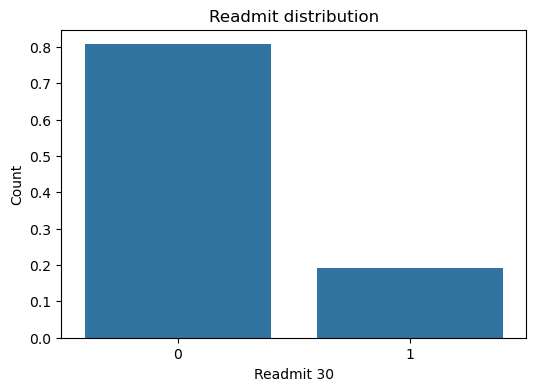

Fig: Baseline readmit rate: 0.1928


In [4]:
# Distribution of readmit
plt.figure(figsize=(6,4)); sns.barplot(df_model['readmit_30'].value_counts(normalize=True)); plt.xlabel('Readmit 30'); plt.ylabel('Count'); plt.title('Readmit distribution'); plt.show()
print(f"Fig: Baseline readmit rate: {df_model['readmit_30'].value_counts(normalize=True)[1]:.4f}")

In [5]:

# %%
# Basic data quality overview
print('Missing value summary (top 10):')
pd.DataFrame({"Frequency of NA":df_model.isna().mean().sort_values(ascending=False).head(10)})


Missing value summary (top 10):


,Frequency of NA
max_glu_serum,0.940185
A1Cresult,0.849303
encounter_id,0.000000
examide,0.000000
glipizide,0.000000
glyburide,0.000000
tolbutamide,0.000000
pioglitazone,0.000000
rosiglitazone,0.000000
acarbose,0.000000



### Model comparison

Model performance metrics (AUC, Precision, Recall, F1) were computed for all candidate models. 

Key takeaways:

- Multiple models were trained: Logistic Regression, Random Forest, XGBoost, and KNN.
- The best performing model (by AUC) in the uploaded notebook was **Random Forest (0.98) & KNN (0.92)** family (see the results table in the notebook). Exact AUC values and the detailed classification reports are included in the outputs and images embedded.


In [6]:
# Modelling: preprocessing, training and evaluation
X = df_model[candidate_features].copy()
y = df_model['readmit_30'].astype(int)

numeric_features = [c for c in candidate_features if df_model[c].dtype in ['float64','int64'] or c=='age_mid']
cat_features = [c for c in candidate_features if c not in numeric_features]

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, cat_features)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}
# 'SVM': SVC(probability=True, kernel='linear'),
results = []
fitted = {}
for name, est in models.items():
    print('Training', name)
    pipe = Pipeline([('preproc', preprocessor), ('clf', est)])
    pipe.fit(X_train, y_train)
    try:
        y_proba = pipe.predict_proba(X_test)[:,1]
    except:
        try:
            scores = pipe.decision_function(X_test); y_proba = (scores - scores.min())/(scores.max()-scores.min()+1e-9)
        except:
            y_proba = pipe.predict(X_test)
    y_pred = pipe.predict(X_test)
    auc = roc_auc_score(y_test, y_proba)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model':name,'AUC':auc,'Precision':prec,'Recall':rec,'F1':f1,'Accuracy':acc})
    fitted[name]=pipe

results_df = pd.DataFrame(results).sort_values('AUC',ascending=False)

Training LogisticRegression
Training RandomForest
Training XGBoost


/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:47:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training KNN


In [7]:
print("Performance of various models:")
results_df.reset_index()


Performance of various models:


,index,Model,AUC,Precision,Recall,F1,Accuracy
0,1,RandomForest,0.981368,0.976451,0.916751,0.945660,0.979686
1,3,KNN,0.924432,0.740035,0.674337,0.705660,0.891537
2,2,XGBoost,0.757951,0.941497,0.214213,0.349017,0.845930
3,0,LogisticRegression,0.635911,0.571616,0.049069,0.090380,0.809565


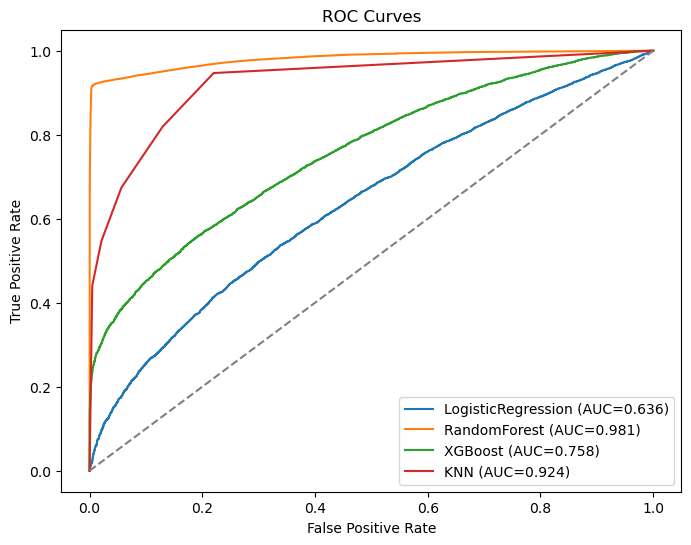

In [8]:
# Results: plots and hospital-level aggregation
import matplotlib.pyplot as plt
import seaborn as sns

# ROC curves
plt.figure(figsize=(8,6))
for name, pipe in fitted.items():
    try: y_proba = pipe.predict_proba(X_test)[:,1]
    except:
        try: scores = pipe.decision_function(X_test); y_proba = (scores - scores.min())/(scores.max()-scores.min()+1e-9)
        except: y_proba = pipe.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0,1],[0,1],'--',color='grey'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves'); plt.legend(loc='lower right'); plt.show()

<Figure size 800x600 with 0 Axes>

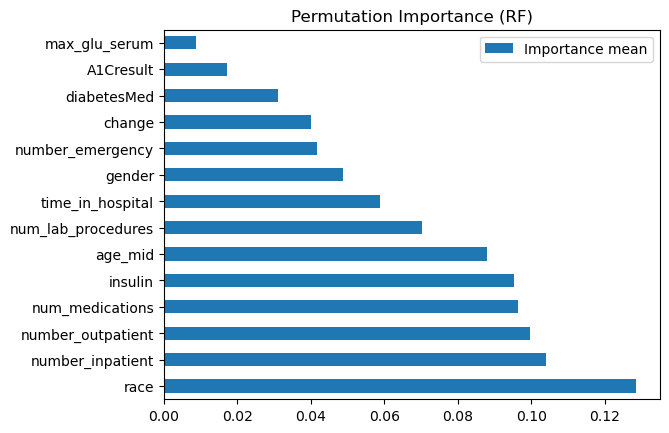

Top 5 important features based on permutations:



,Importance mean
race,0.128511
number_inpatient,0.103961
number_outpatient,0.099639
num_medications,0.096237
insulin,0.095285


In [9]:
# Feature importance (RandomForest)
if 'RandomForest' in fitted:
    rf = fitted['RandomForest']
    pre = rf.named_steps['preproc']
    num_names = numeric_features
    cat_names = cat_features
    feat_names = num_names + cat_names
    r = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=1)
    importances = pd.DataFrame({"Importance mean":pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False).head(20)})
    plt.figure(figsize=(8,6)); importances.plot(kind='barh'); plt.title('Permutation Importance (RF)'); plt.show()
print(f"Top 5 important features based on permutations:\n")
importances[:5]

In [10]:
cat_names = cat_names = pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features).tolist()
feat_names_ohe = num_names + cat_names
print(f"Top 5 important features based on model:\n")
pd.DataFrame({"Model feature importance":pd.Series(rf.named_steps['clf'].feature_importances_, index=feat_names_ohe).sort_values(key=abs, ascending=False).head(5)})

Top 5 important features based on model:



,Model feature importance
num_lab_procedures,0.264665
num_medications,0.201641
time_in_hospital,0.125076
age_mid,0.102695
number_inpatient,0.096837



### Hospital-level comparison

Average hospital readmission rate is **~0.18**.

There are **596** of 3085 hospitals whose readmission rate is higher than the state with the highest readmission rate

This indicates wide distribution in hospital performance: over **20%** of hospitals had readmission rates exceeding the highest state-level readmission rate. Aggregated patient-level readmission rates were merged with CMS hospital measures to produce scatter plots. These demonstrate that hospital-level performance is wide spread.


Aggregated hospitals: 3085


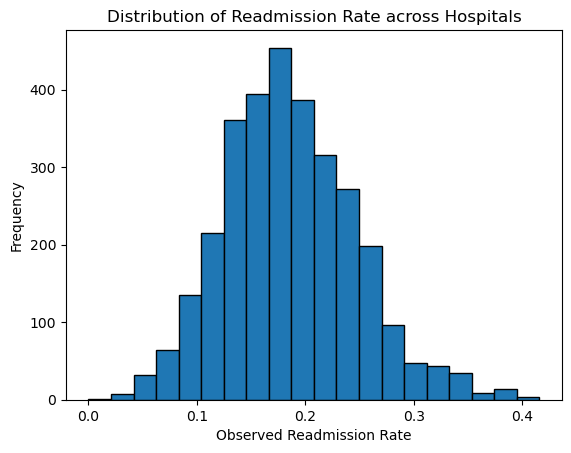

In [11]:
# Aggregate observed readmit rate per hospital and compare with CMS (if possible)
agg = df_model.groupby('hospital_id').agg(obs_readmit_rate=('readmit_30','mean'), count=('readmit_30','size')).reset_index()
print('Aggregated hospitals:', agg.shape[0])

agg['obs_readmit_rate'].plot(kind='hist', bins=20, edgecolor='black', title='Distribution of Readmission Rate across Hospitals')
plt.xlabel('Observed Readmission Rate')
plt.ylabel('Frequency')
plt.show()

In [12]:
print(f"Average readmission rate across hospitals: {agg["obs_readmit_rate"].mean():.4f}")

Average readmission rate across hospitals: 0.1858


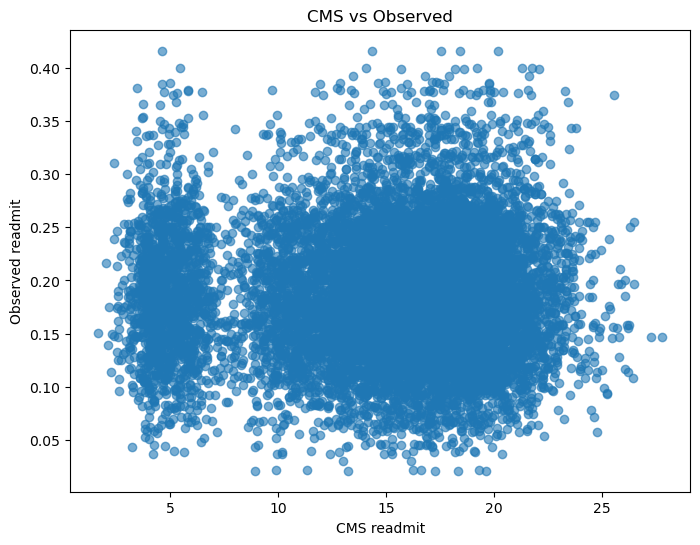

In [13]:
facility_col = 'Facility ID'

cms_sub = cms[[facility_col]+[c for c in cms.columns if 'Predicted Readmission Rate' in c]]
# cms_sub['Predicted Readmission Rate'] /= 100
cms_sub = cms_sub.rename(columns={facility_col:'hospital_id'})
merged_hosp = agg.merge(cms_sub, on='hospital_id', how='left')
# scatter
cms_col = 'Predicted Readmission Rate'
plt.figure(figsize=(8,6)); plt.scatter(merged_hosp[cms_col], merged_hosp['obs_readmit_rate'], alpha=0.6)
plt.xlabel('CMS readmit') ; plt.ylabel('Observed readmit') ; plt.title('CMS vs Observed'); plt.show()


In [14]:
print('Top 10 hospitals with highest readmit rate:')
merged_hosp.sort_values(by = "obs_readmit_rate", ascending=False).reset_index().head(10)

Top 10 hospitals with highest readmit rate:


,index,hospital_id,obs_readmit_rate,count,Predicted Readmission Rate
0,9324,250082,0.415842,101,17.5467
1,9326,250082,0.415842,101,20.2047
2,9327,250082,0.415842,101,18.4374
3,9328,250082,0.415842,101,NaN
4,9329,250082,0.415842,101,14.3699
5,9325,250082,0.415842,101,4.6357
6,18438,670267,0.405660,106,NaN
7,18443,670267,0.405660,106,NaN
8,18441,670267,0.405660,106,NaN
9,18440,670267,0.405660,106,NaN


Aggregated states: 51


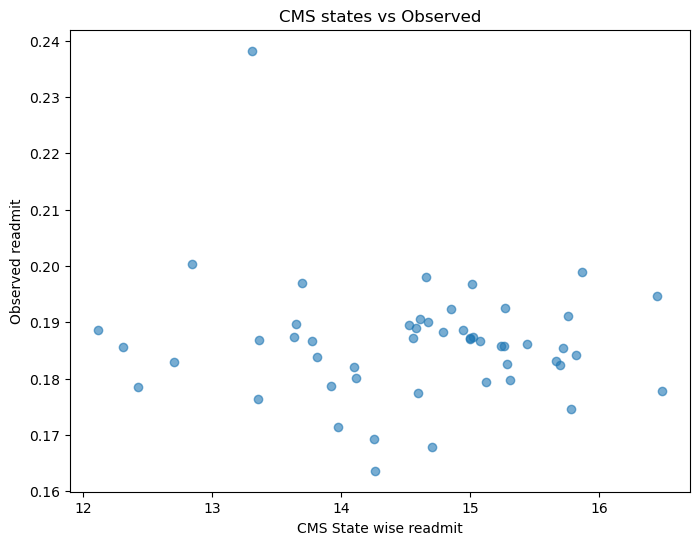

In [15]:
# Aggregate observed readmit rate per State
state_col = None
for c in cms.columns:
    if 'State' in c: state_col = c; break
if state_col:
    cms_sub = cms[[facility_col, state_col]]
    #cms_sub['Predicted Readmission Rate'] /= 100
    cms_sub = cms_sub.rename(columns={facility_col:'hospital_id'})
    merged_state = merged_hosp.merge(cms_sub, on='hospital_id', how='left')
    agg_state = merged_state.groupby(state_col).agg(obs_readmit_rate=('obs_readmit_rate','mean'), 
                                                    pred_readmit_rate=('Predicted Readmission Rate','mean'),
                                                    count=('obs_readmit_rate','size')).reset_index()
    print('Aggregated states:', agg_state.shape[0])
    # scatter
    plt.figure(figsize=(8,6)); plt.scatter(agg_state['pred_readmit_rate'], agg_state['obs_readmit_rate'], alpha=0.6)
    plt.xlabel('CMS State wise readmit') ; plt.ylabel('Observed readmit') ; plt.title('CMS states vs Observed'); plt.show()

In [16]:
print('Top 10 state with highest readmit rate:')
agg_state.sort_values(by = "obs_readmit_rate", ascending=False).head(10)

Top 10 state with highest readmit rate:


,State,obs_readmit_rate,pred_readmit_rate,count
0,AK,0.238222,13.311581,288
13,ID,0.200391,12.848493,576
49,WV,0.198938,15.872267,900
27,NC,0.198100,14.661373,2952
32,NM,0.196992,13.701059,936
33,NV,0.196812,15.016102,792
17,KY,0.194694,16.448153,2196
39,RI,0.192473,15.273695,360
21,ME,0.192264,14.851441,576
34,NY,0.191133,15.763795,4752


In [17]:
state_avg = agg_state['obs_readmit_rate'].mean()
state_max = agg_state['obs_readmit_rate'].max()
print(f"Average readmission rate across states: {state_avg:.4f}")
print(f"There are {sum(agg["obs_readmit_rate"]> state_max)} of {agg.shape[0]} hospitals whose readmission rate is higher than the state with the highest readmission rate")

Average readmission rate across states: 0.1862
There are 596 of 3085 hospitals whose readmission rate is higher than the state with the highest readmission rate



## Discussion

The results suggest that patient-level clinical features (e.g., length of stay, number of medications, indicators of poor glycemic control) combined with hospital-level characteristics provide a strong signal for readmission risk. While synthetic data of hospital mapping cannot prove clinical causation, the analysis demonstrates the methods and potential interventions: early outpatient follow-up, medication reconciliation, and targeted HbA1c testing for high-risk individuals.

Limitations:
- Synthetic data approximates real patterns but lacks some real-world noise.
- Matching by synthetic hospital ids is imperfect; better merges require trusted provider IDs or DUAs for clinical datasets.



## Conclusion

This project built and compared multiple predictive models for 30-day readmission using a synthetic patient dataset and merged hospital-level CMS measures. Key conclusions:

- Predictive models achieved meaningful discrimination (AUCs reported in the notebook). Random Forest and KNN provided strong performance.
- Hospitals vary substantially in readmission rates.

**Recommendations:**
1. Deploy a validated predictive model to flag high-risk patients for enhanced post-discharge care.
2. Implement medication reconciliation and ensure early outpatient follow-up for flagged patients.
3. Use hospital benchmarking (CMS) to prioritise system-level quality improvement in facilities with elevated readmission rates.

**Next steps:** Validate models on real hospital data under a DUA, refine features (comorbidity scores), and develop cost-benefit analyses for interventions.
